# Purpose
Goal is to use a few input points to generate all the Zaber coordinates (and then mm coordinates) for the tile centers and produce a csv for use in Bonsai. Also, it would be nice to get all the tile pole locations for making simulations (making hexes, etc.)

# imports

In [1]:
import os, sys, math
from datetime import datetime
import tifffile as tif
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd

# functions

In [2]:
def get_row_vals(centers,index_of_centers,length_of_row):
    ''' function to auto-generate row values from a single center val
    INPUTS:
        1. centers: a tuple or list of center values for a tile in Zaber units (e.g. ls = 238800, ax=47200 the input would be [238800,47200] or (238800,47200))
        2. index_of_centers: an integer indicating which tile value you're inputting (e.g. M1 = element 0, M2 = element 1... etc)
        3. length_of_row: an integer indicating how many tiles in the row (e.g. 1 if A, 4 if B... 13 if M... 1 if Q)
    OUTPUTS:
        two lists ls_row_vals and ax_row_vals
    EXAMPLE:
        M1c = (230100, 46500)
        M_ls_cs,M_ax_cs = get_row_vals(M1c,0,13)
        print(M_ls_cs)
        print(M_ax_cs)
        > [230100, 228100, 226100, 224100, 222100, 220100, 218100, 216100, 214100, 212100, 210100, 208100, 206100]
        > [46500, 67700, 88900, 110100, 131300, 152500, 173700, 194900, 216100, 237300, 258500, 279700, 300900]
        
    NOTE: if you have K2c, try
        K_ls_cs, K_ax_cs = get_row_vals(K2c,1,13) because K2 is the 1st element in the list of K tile values from 1-13
    '''
    ls_row_offset = -1400
    ax_row_offset= 21400
    print('using ls_row_offset of {} and ax_row_offset of {}'.format(ls_row_offset,ax_row_offset))
    ls = centers[0]
    ax = centers[1]
    ls_row_vals=[]
    ax_row_vals=[]
    for i in np.arange(0-index_of_centers,length_of_row-index_of_centers):
        ls_row_vals.append(ls+i*ls_row_offset)
        ax_row_vals.append(ax+i*ax_row_offset)
    return ls_row_vals, ax_row_vals

In [23]:
def get_neighbor_tile(centers,direction):
    ''' INPUTS
        1. centers: a tuple or list of center values for a tile in Zaber units (e.g. ls = 238800, ax=47200 the input would be [238800,47200] or (238800,47200))
        2. direction: an int, either 0 for above right or 1 for below right (e.g. to get M2 from L2, use 1. to get L1 from M1, use 0)
        
        TODO later I should make this more flexible and harder to mess up
        OUTPUTS:
        1. new list with the center values in [ls,ax]
    '''
    ls = centers[0]
    ax = centers[1]
    M1_to_L1_offset = [-19500,9200]
    L1_to_M2_offset = [17600,12200]
    if direction == 0:
        new_centers = [ls+M1_to_L1_offset[0],ax+M1_to_L1_offset[1]]
        #print('generated the tile center above and right of the values provided (e.g. M1 center entered, want L1 centers) using {} offset'.format(M1_to_L1_offset))
    elif direction == 1:
        new_centers = [ls+L1_to_M2_offset[0],ax+L1_to_M2_offset[1]]
        #print('generated the tile center from below and right of the values provided (e.g. L1 center entered, want M2 centers) using {} offset'.format(L1_to_M2_offset))
    else:
        print('ERROR: you entered {}, which must be either 0 (for above, right) or 1 (for below, right)')
        new_centers=[]
    return new_centers

In [4]:
def get_relative_vals(df, location1, location2, adj_val):
    '''
    INPUTS: 
        1. df: a pandas DataFrame with three columns: name, ls_guess, and ax_new_guess
        2. 
        3. 
        4. adj_val = adjust the outputs by this amount
    OUTPUTS:
        1. ls_high the highest ls value as an integer
        2. ls_low the lowest ls value as an integer
        3. ax_high the highest ax value as an integer
        4. ax_low the lowest ax value as an integer
    '''
    ax1= int(df.ax_new_guess[df.name==location1]/100)
    ax2 = int(df.ax_new_guess[df.name==location2]/100)
    ls1= int(df.ls_guess[df.name==location1]/100)
    ls2 = int(df.ls_guess[df.name==location2]/100)
    if ls1 > ls2:
        ls_high = ls1
        ls_low = ls2
    else:
        ls_low = ls1
        ls_high = ls2
    if ax1 > ax2:
        ax_low = ax2
        ax_high = ax1
    else:
        ax_low = ax1
        ax_high = ax2
    return ls_high+adj_val,ls_low-adj_val,ax_high+adj_val,ax_low-adj_val

In [5]:
def get_closest(list_input,num):
    aux = []
    for val in list_input:
        aux.append(abs(num-val))

    return aux.index(min(aux))

In [6]:
def getpoints(p1, p2):
    # Sort both points first.
    (x1, y1), (x2, y2) = sorted([p1, p2])
    a = b = 0.0
    yvals=[]
    xvals=np.arange(int(x1), int(x2) + 1)    
    # First point is in (0, y).
    if x1 == 0.0:
        b = y1
        a = (y2 - y1) / x2
    elif x2 == 0.0:
        # Second point is in (0, y).
        b = y2
        a = (y1 - y2) / x1
    else:
        # Both points are valid.
        b = (y2 - (y1 * x2) / x1) / (1 - (x2 / x1))
        a = (y1 - b) / x1
        for x in xvals:
            yvals.append(a * float(x) + b)
    yvals=[round(val) for val in yvals]
    axs=[]
    lss=[]
    for val in np.arange(np.min(yvals),np.max(yvals)):
        i=get_closest(yvals,val) # gets integer of yval closest
        lss.append(xvals[i])
        axs.append(yvals[i])
    return (lss, axs)

In [7]:
def rot_list_of_ax_ls(ax_list,ls_list,angle):
    # first check lists are same length
    if len(ax_list)!=len(ls_list):
        print('ERROR, your lists are two different lengths! 1st argument, ax_list is {} and 2nd argument ls_list is {}'.format(len(ax_list),len(ls_list)))
    else:
        ax_new=[]
        ls_new=[]
        
        ax_com=np.mean(ax_list)
        ls_com = np.mean(ls_list)
        ax_corr = ax_list-ax_com
        ls_corr = ls_list-ls_com
        print('using angle of {} degrees'.format(angle))
        alfa = angle*math.pi/180
        for i in range(len(ax_list)):
            ax_new.append((math.cos(alfa)*ax_corr[i]-math.sin(alfa)*ls_corr[i])+ax_com)
            ls_new.append((math.sin(alfa)*ax_corr[i]+math.cos(alfa)*ls_corr[i])+ls_com)
    return [ax_new,ls_new]

SyntaxError: invalid syntax (3493022552.py, line 1)

In [43]:
# from A1 top
A1_top_ls= 9200
A1_top_ax= 160400

# middle val = top + offset
# middle - top = offset
middle_from_0_offset = [227900-219000,57300-56600]
middle_from_0_offset

# get M1 center
A1c = (A1_top_ls+middle_from_0_offset[0],A1_top_ax+middle_from_0_offset[1])
print(A1c)
# get L centers (12)
B3c = get_neighbor_tile(A1c,1)
B_ls_cs,B_ax_cs = get_row_vals(B3c,2,)
print(B1c)

(18100, 161100)
using ls_row_offset of -1400 and ax_row_offset of 21400
38500 130500


In [44]:
# get K centers, using K2
K2c=get_neighbor_tile(L1c,0)
print(K2c)
K_ls_cs,K_ax_cs = get_row_vals(K2c,1,13)

NameError: name 'L1c' is not defined

In [42]:
# get Js, Hs, Fs
# J from L
J1c = get_neighbor_tile([K_ls_cs[0],K_ax_cs[0]],0)
print('j1c {}'.format(J1c))
J_ls_cs,J_ax_cs = get_row_vals(J1c,0,12)

I2c = get_neighbor_tile(J1c,0)
I_ls_cs,I_ax_cs = get_row_vals(I2c,1,13)
print('i2c {}'.format(I2c))

H1c = get_neighbor_tile([I_ls_cs[0],I_ax_cs[0]],0)
print('h1c {}'.format(H1c))
H_ls_cs,H_ax_cs = get_row_vals(H1c,0,12)

G2c = get_neighbor_tile(H1c,0)
G_ls_cs,G_ax_cs = get_row_vals(G2c,1,13)
print('g2c {}'.format(G2c))

F2c = get_neighbor_tile(G2c,0)
F_ls_cs,F_ax_cs = get_row_vals(F2c,1,12)

E2c = get_neighbor_tile([F_ls_cs[0],F_ax_cs[0]],0)
E_ls_cs,E_ax_cs = get_row_vals(E2c,1,13)
print('E2c {}'.format(E2c))

# get D1 from E2, make 10 Ds
D1c=get_neighbor_tile(E2c,0)
D_ls_cs,D_ax_cs = get_row_vals(D1c,0,10)
print('D1c {}'.format(D1c))
# get C1 from D2, make 7 Cs
C1c = get_neighbor_tile([D_ls_cs[1],D_ax_cs[1]],0)
C_ls_cs,C_ax_cs = get_row_vals(C1c,0,7)
print('C1c {}'.format(C1c))
# get B1 from C2, make 4 Bs
B1c = get_neighbor_tile([C_ls_cs[1],C_ax_cs[1]],0)
B_ls_cs,B_ax_cs = get_row_vals(B1c,0,4)
print('B1c {}'.format(B1c))
# get A1 from B2
A1c = get_neighbor_tile([B_ls_cs[1],B_ax_cs[1]],0)
A_ls_cs = [A1c[0]]
A_ax_cs = [A1c[1]]

# get N1 from M2, get 10 Ns
N1c = get_neighbor_tile([M_ls_cs[1],M_ax_cs[1]],1)
N_ls_cs,N_ax_cs = get_row_vals(N1c,0,10)

# get O1 from N2, get 7 Os
O1c = get_neighbor_tile([N_ls_cs[1],N_ax_cs[1]],1)
O_ls_cs,O_ax_cs = get_row_vals(O1c,0,7)

# get P1 from O2, get 4 Ps
P1c = get_neighbor_tile([O_ls_cs[1],O_ax_cs[1]],1)
P_ls_cs,P_ax_cs = get_row_vals(P1c,0,4)

# g15 Q1 from Ps
Q1c = get_neighbor_tile([P_ls_cs[1],P_ax_cs[1]],1)
Q_ls_cs = [Q1c[0]]
Q_ax_cs = [Q1c[1]]

NameError: name 'K_ls_cs' is not defined

In [25]:
all_ax_cs = [A_ax_cs,B_ax_cs,C_ax_cs,D_ax_cs,E_ax_cs,F_ax_cs,G_ax_cs,H_ax_cs,I_ax_cs,J_ax_cs,K_ax_cs,L_ax_cs,M_ax_cs,N_ax_cs,O_ax_cs,P_ax_cs,Q_ax_cs]
all_ls_cs = [A_ls_cs,B_ls_cs,C_ls_cs,D_ls_cs,E_ls_cs,F_ls_cs,G_ls_cs,H_ls_cs,I_ls_cs,J_ls_cs,K_ls_cs,L_ls_cs,M_ls_cs,N_ls_cs,O_ls_cs,P_ls_cs,Q_ls_cs]

NameError: name 'A_ax_cs' is not defined

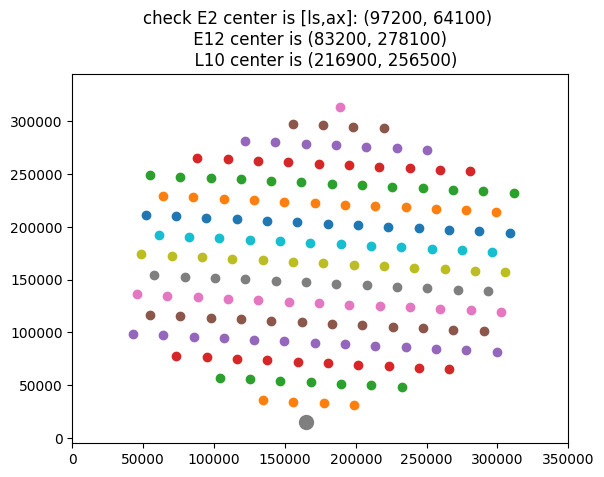

In [105]:
for i in np.arange(0,len(all_ax_cs)):
    plt.scatter(all_ax_cs[i],all_ls_cs[i])
plt.scatter(all_ax_cs[0],all_ls_cs[0],s=100)
    
plt.xlim([0,350000])
plt.ylim([-5000,345000])
plt.title('check E2 center is [ls,ax]: {} \n E12 center is {} \n  L10 center is {}'.format((E_ls_cs[1],E_ax_cs[1]),(E_ls_cs[11],E_ax_cs[11]),(L_ls_cs[9],L_ax_cs[9])))
#plt.scatter(current_file.ax_new_guess,current_file.ls_guess,c='k',alpha=0.2)
plt.show()

In [107]:
alpha = 'ABCDEFGHIJKLMNOPQ'
numera = np.arange(1,14).astype(str)
print(alpha,numera)

ABCDEFGHIJKLMNOPQ ['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13']


In [24]:
names = []
ls_guesses = []
ax_new_guesses = []

for i in np.arange(0,len(all_ax_cs)):
    print(i)
    curr_ax = all_ax_cs[i]
    curr_ls = all_ls_cs[i]

    for j in np.arange(0,len(curr_ax)):
        names.append(alpha[i]+numera[j])
        ls_guesses.append(int(curr_ls[j]))
        ax_new_guesses.append(int(curr_ax[j]))
new_dict = {'name':names,'ls_guess':ls_guesses,'ax_new_guess':ax_new_guesses}
new_csv = pd.DataFrame(new_dict)        

NameError: name 'all_ax_cs' is not defined

In [111]:
?new_csv.to_csv

In [112]:
# create name and save out file
now = datetime.now()
filestring = "../../../data/zaber_centers_"+now.strftime("%Y%m%d")+".csv"
filestring
new_csv.to_csv(filestring,index=False)

# image files

In [29]:
new_csv= pd.read_csv('/Users/emily/Desktop/data/zaber_centers.csv')

In [31]:
adj_val=50 #adds/subtracts adj_val*100 zaber units to the edges. They're usually too close to the edge.

In [41]:
E_ax_cs

NameError: name 'E_ax_cs' is not defined

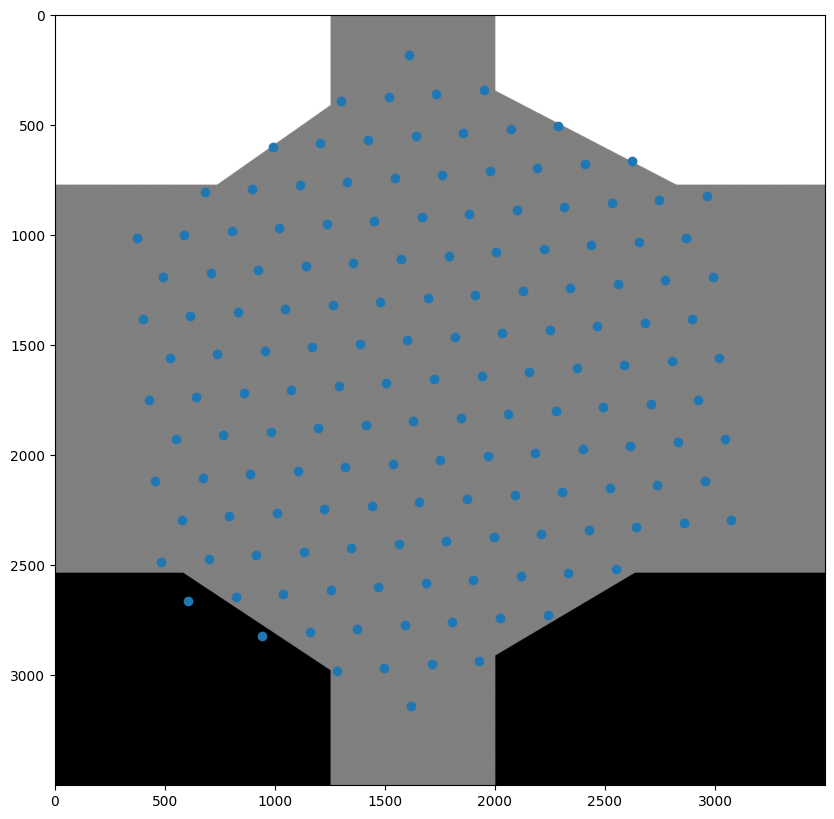

In [40]:
new_ls = np.zeros((3500,3500,3))

# fill vertical stripe from top to bottom
[ls_high,ls_low,ax_high,ax_low]=get_relative_vals(new_csv,"B1","B4",adj_val)
new_ls[0:3500,ax_low:ax_high]=128
b_left = ax_low
b_right = ax_high

# fill horizontal stripe from ax 0 to 3000 and 
# ...highest ls btw E1,E13 and lowest ls between M1,M13
[ls_high,ls_low,ax_high,ax_low]=get_relative_vals(new_csv,"E1","E13",adj_val)
start = ls_low
[ls_high,ls_low,ax_high,ax_low]=get_relative_vals(new_csv,"M1","M13",adj_val)
end = ls_high
new_ls[start:end,0:3500]=128

# use above #s to fill in white on 'top', will be partially overwritten next
new_ls[0:start,0:b_left]=255
new_ls[0:start,b_right:3500]=255

# now add triangles to finish the hexagon
# fill between M1,P1 (bottom left triangle on image)
[ls_high,ls_low,ax_high,ax_low]=get_relative_vals(new_csv,"M1","P1",adj_val)
[lss,axs] = getpoints((ls_high,ax_high),(ls_low,ax_low-1)) # returns integer locations on line
for i in np.arange(1,len(lss)):
    new_ls[end:lss[i],axs[i-1]:axs[i]]=128
    
# fill between P4/M13 (bottom right triangle on image)
[ls_high,ls_low,ax_high,ax_low]=get_relative_vals(new_csv,"P4","M13",adj_val)
[lss,axs] = getpoints((ls_high,ax_low),(ls_low,ax_high+1)) # returns integer locations on line
for i in np.arange(1,len(lss)):
    if axs[i] < 3500:
        new_ls[ls_low:lss[i],axs[i-1]:axs[i]]=128

# there may be a gap on the bottom right inside the arena, fill it
new_ls[ls_low:3500,b_left:np.min(axs)]=128

# fill between E1/B1 (top left triangle on image)
[ls_high,ls_low,ax_high,ax_low]=get_relative_vals(new_csv,"E1","B1",adj_val)
#E1 is high ls, low ax
[lss,axs] = getpoints((ls_high,ax_low),(ls_low,ax_high+1)) # returns integer locations on line
# fill from val to high_ls from ax-1 to ax
for i in np.arange(1,len(lss)):
    if axs[i]<3500:
        new_ls[lss[i]:ls_high,axs[i-1]:axs[i]]=128


# fill between B4/E13 (top right triangle on image), B4 is low/low
[ls_high,ls_low,ax_high,ax_low]=get_relative_vals(new_csv,"B4","E13",adj_val)
[lss,axs] = getpoints((ls_low,ax_low),(ls_high,ax_high+1)) # returns integer locations on line
# fill from val to high_ls, ax-1 to ax
for i in np.arange(1,len(lss)):
    if axs[i]<3500:
        new_ls[lss[i]:ls_high,axs[i-1]:axs[i]]=128

plt.figure(figsize=(20,10))
plt.imshow(new_ls/255)
plt.scatter(new_csv.ax_new_guess/100, new_csv.ls_guess/100)

In [115]:
now = datetime.now()
ls_tif_filestring = "../../../data/rig_l_mult_"+now.strftime("%Y%m%d")+".tif"
tif.imsave(ls_tif_filestring,new_ls.astype('uint8'),photometric='rgb')

## now make AX

2984 2272 3165 2147
768 2540 377 3165


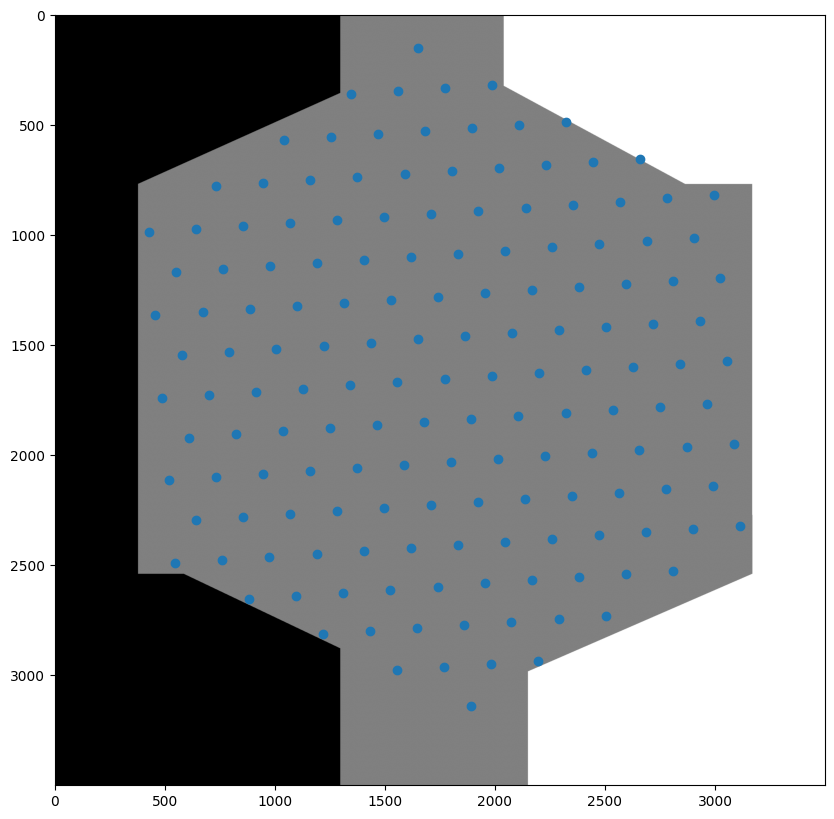

In [116]:
new_ax = np.zeros((3500,3500,3))

# first fill everything right of the middle with white
# B4 P4 get lowest ax value
[ls_high,ls_low,ax_high,ax_low]=get_relative_vals(new_csv,"B4","P4",adj_val)
new_ax[:,ax_low:3500]=255

# next fill a vertical stripe
[ls_high,ls_low,ax_high,ax_low]=get_relative_vals(new_csv,"B1","B4",adj_val)
new_ax[0:3500,ax_low:ax_high]=128
b_left = ax_low
b_right = ax_high

# next make a box from low_ls between E1/E13 and high ls between M1/M13 and low ax E1/M1 and high ax E13/M13
[ls_high,ls_low,ax_high,ax_low]=get_relative_vals(new_csv,"E1","E13",adj_val)
a = ls_low
[ls_high,ls_low,ax_high,ax_low]=get_relative_vals(new_csv,"M1","M13",adj_val)
b = ls_high
[ls_high,ls_low,ax_high,ax_low]=get_relative_vals(new_csv,"E1","M1",adj_val)
c = ax_low
[ls_high,ls_low,ax_high,ax_low]=get_relative_vals(new_csv,"E13","M13",adj_val)
d = ax_high
if d < 3500:
    new_ax[a:b,c:d]=128
else:
    new_ax[a:b,c:3500]=128
    
#now add triangles to finish the hexagon
# fill between M1,P1 (bottom left triangle on image)
[ls_high,ls_low,ax_high,ax_low]=get_relative_vals(new_csv,"M1","P1",adj_val)
[lss,axs] = getpoints((ls_high,ax_high),(ls_low,c-1)) # returns integer locations on line
for i in np.arange(1,len(lss)):
    new_ax[b:lss[i],axs[i-1]:axs[i]]=128

# fill between P4/M13 (bottom right triangle on image)
[ls_high,ls_low,ax_high,ax_low]=get_relative_vals(new_csv,"P4","M13",adj_val)
[lss,axs] = getpoints((ls_high,ax_low),(b,ax_high+1)) # returns integer locations on line
for i in np.arange(1,len(lss)):
    if axs[i] < 3500:
        new_ax[ls_low:lss[i],axs[i-1]:axs[i]]=128
print(ls_high,ls_low,ax_high,ax_low)
print(a,b,c,d)

# there may be a gap on the bottom right inside the arena, fill it
new_ax[ls_low:3500,b_left:np.min(axs)]=128

# fill between E1/B1 (top left triangle on image)
[ls_high,ls_low,ax_high,ax_low]=get_relative_vals(new_csv,"E1","B1",adj_val)
#E1 is high ls, low ax
[lss,axs] = getpoints((a,ax_low),(ls_low,ax_high+1)) # returns integer locations on line
# fill from val to high_ls from ax-1 to ax
for i in np.arange(1,len(lss)):
    if axs[i]<3500:
        new_ax[lss[i]:ls_high,axs[i-1]:axs[i]]=128

# fill between B4/E13 (top right triangle on image), B4 is low/low
[ls_high,ls_low,ax_high,ax_low]=get_relative_vals(new_csv,"B4","E13",adj_val)
[lss,axs] = getpoints((ls_low,ax_low),(ls_high,ax_high+1)) # returns integer locations on line
# fill from val to high_ls, ax-1 to ax
for i in np.arange(1,len(lss)):
    if axs[i]<3500:
        new_ax[lss[i]:ls_high,axs[i-1]:axs[i]]=128
        

plt.figure(figsize=(20,10))
plt.imshow(new_ax/255)
plt.scatter(new_csv.ax_new_guess/100, new_csv.ls_guess/100)

In [117]:
now = datetime.now()
ls_tif_filestring = "../../../data/rig_ax_mult_"+now.strftime("%Y%m%d")+".tif"
tif.imsave(ls_tif_filestring,new_ax.astype('uint8'),photometric='rgb')